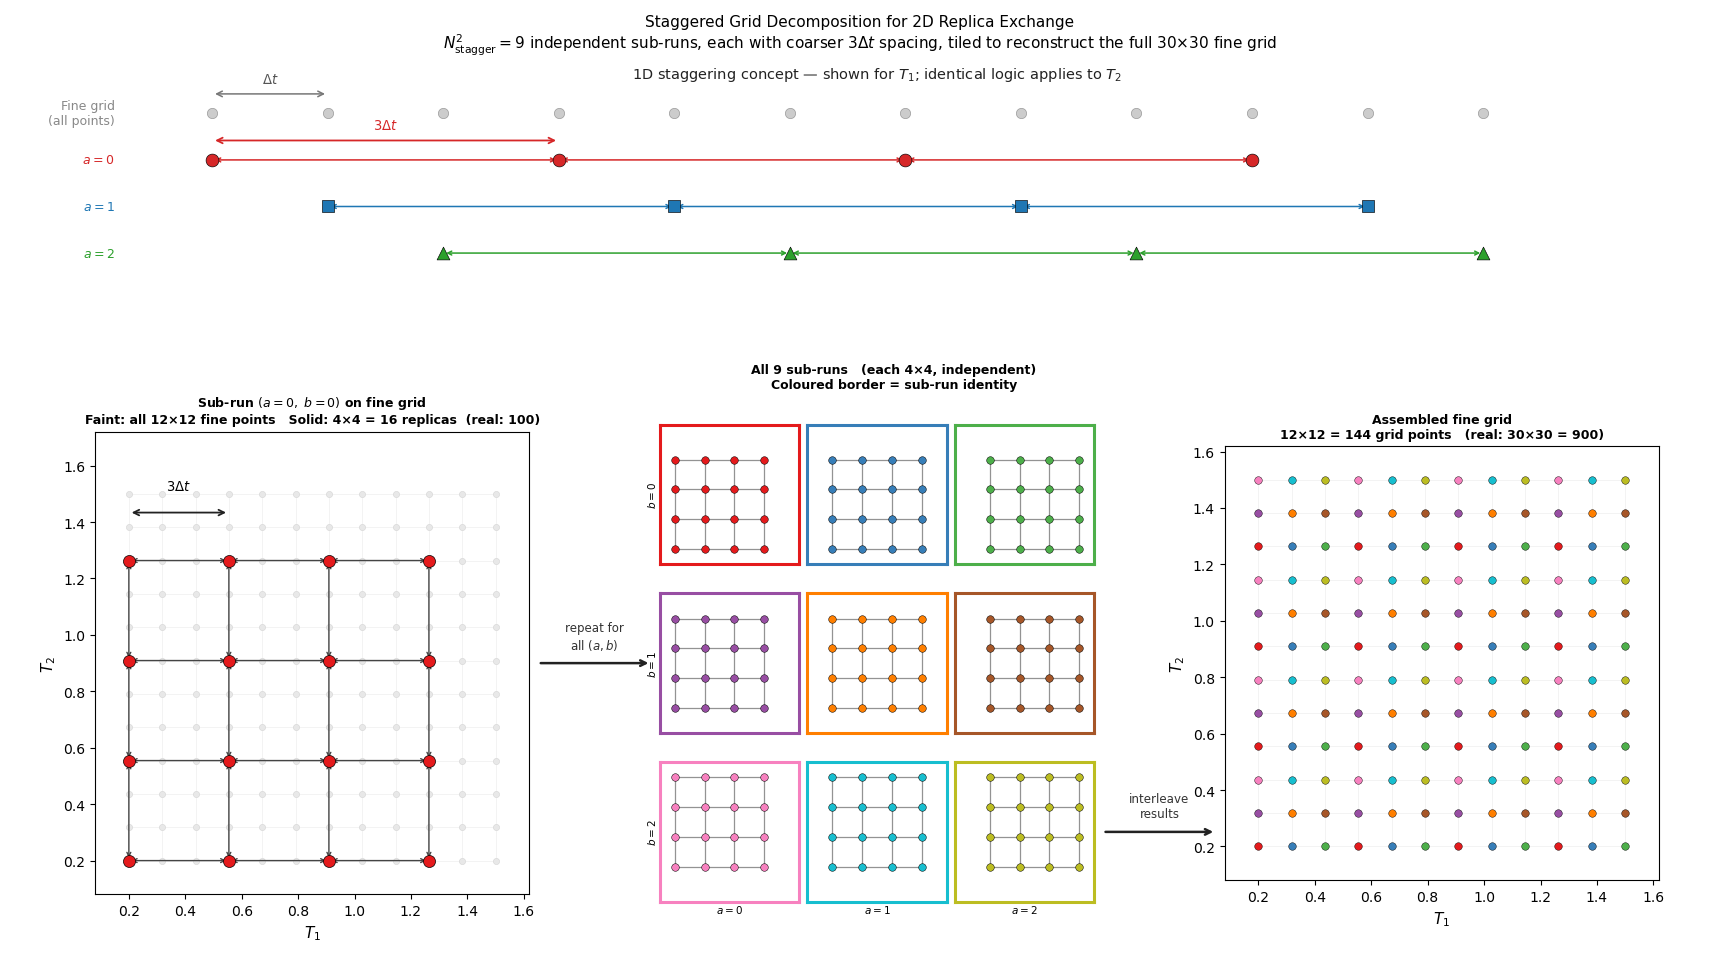

Saved.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Parameters ────────────────────────────────────────────────────────────────
N_S = 3                        # N_STAGGER
N_T = 4                        # replicas per axis per sub-run  (real: 10)
N_F = N_T * N_S                # fine grid size = 12            (real: 30)
T   = np.linspace(0.2, 1.5, N_F)

_pal = ['#e41a1c','#377eb8','#4daf4a',
        '#984ea3','#ff7f00','#a65628',
        '#f781bf','#17becf','#bcbd22']
C    = {(a, b): _pal[b * N_S + a] for b in range(N_S) for a in range(N_S)}
a_col = ['#d62728','#1f77b4','#2ca02c']

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 9.5))
gs_outer = gridspec.GridSpec(
    2, 3, figure=fig,
    height_ratios=[1.05, 2.8],
    hspace=0.42, wspace=0.30,
    left=0.05, right=0.97, top=0.92, bottom=0.05,
)
ax_1d  = fig.add_subplot(gs_outer[0, :])
ax_ex  = fig.add_subplot(gs_outer[1, 0])
gs_9   = gridspec.GridSpecFromSubplotSpec(N_S, N_S, subplot_spec=gs_outer[1, 1],
                                           hspace=0.06, wspace=0.06)
ax_asm = fig.add_subplot(gs_outer[1, 2])

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 0 — 1D STAGGERING CONCEPT
# ═══════════════════════════════════════════════════════════════════════════════
ax_1d.set_xlim(T[0] - 0.12, T[-1] + 0.18)
ax_1d.set_ylim(-0.55, 4.05)
ax_1d.axis('off')

rows = [3.35, 2.2, 1.05, -0.1]
mkr  = ['o', 'o', 's', '^']

for t in T:
    ax_1d.scatter(t, rows[0], c='#cccccc', s=55, marker='o', zorder=3,
                  edgecolors='#999999', linewidths=0.5)

for a in range(N_S):
    Ts = T[a::N_S]
    for t in Ts:
        ax_1d.scatter(t, rows[a+1], c=a_col[a], s=85, marker=mkr[a+1],
                      zorder=3, edgecolors='k', linewidths=0.45)
    for k in range(len(Ts)-1):
        ax_1d.annotate('', xy=(Ts[k+1], rows[a+1]), xytext=(Ts[k], rows[a+1]),
                       arrowprops=dict(arrowstyle='<->', color=a_col[a],
                                       lw=1.1, mutation_scale=7), zorder=2)

lbls = ['Fine grid\n(all points)', '$a = 0$', '$a = 1$', '$a = 2$']
cols = ['#888888'] + a_col
for y, lbl, col in zip(rows, lbls, cols):
    ax_1d.text(T[0] - 0.10, y, lbl, ha='right', va='center', fontsize=9,
               color=col, fontweight='bold' if col != '#888888' else 'normal')

# Fine-grid spacing annotation
y0 = rows[0] + 0.48
ax_1d.annotate('', xy=(T[1], y0), xytext=(T[0], y0),
               arrowprops=dict(arrowstyle='<->', color='#777777', lw=1.1))
ax_1d.text((T[0]+T[1])/2, y0+0.20, r'$\Delta t$',
           ha='center', va='bottom', fontsize=9.5, color='#555555')

# Sub-run spacing annotation (3×)
Ts0 = T[0::N_S]
y1  = rows[1] + 0.48
ax_1d.annotate('', xy=(Ts0[1], y1), xytext=(Ts0[0], y1),
               arrowprops=dict(arrowstyle='<->', color=a_col[0], lw=1.3))
ax_1d.text((Ts0[0]+Ts0[1])/2, y1+0.20, r'$3\Delta t$',
           ha='center', va='bottom', fontsize=9.5, color=a_col[0], fontweight='bold')

ax_1d.set_title(r'1D staggering concept — shown for $T_1$; identical logic applies to $T_2$',
                fontsize=10.5, pad=5, color='#222222')

# ═══════════════════════════════════════════════════════════════════════════════
# BOTTOM LEFT — ONE EXAMPLE SUB-RUN OVERLAID ON FINE GRID
# ═══════════════════════════════════════════════════════════════════════════════
pad = 0.12
a0, b0 = 0, 0
T1s = T[a0::N_S]
T2s = T[b0::N_S]

T1m_f, T2m_f = np.meshgrid(T, T)
ax_ex.scatter(T1m_f, T2m_f, c='#e8e8e8', s=20, zorder=1,
              edgecolors='#cccccc', linewidths=0.3)
for t in T:
    ax_ex.plot(T, np.full(N_F, t), '-', color='#eeeeee', lw=0.5, zorder=0)
    ax_ex.plot(np.full(N_F, t), T, '-', color='#eeeeee', lw=0.5, zorder=0)

aw = dict(arrowstyle='<->', color='#444444', lw=1.0, mutation_scale=7)
for t2 in T2s:
    for k in range(len(T1s)-1):
        ax_ex.annotate('', xy=(T1s[k+1], t2), xytext=(T1s[k], t2),
                       arrowprops=aw, zorder=3)
for t1 in T1s:
    for k in range(len(T2s)-1):
        ax_ex.annotate('', xy=(t1, T2s[k+1]), xytext=(t1, T2s[k]),
                       arrowprops=aw, zorder=3)

T1m, T2m = np.meshgrid(T1s, T2s)
ax_ex.scatter(T1m, T2m, c=C[(a0, b0)], s=75, zorder=5,
              edgecolors='k', linewidths=0.5)

# 3Δt annotation — use clip_on=False on the text instead of annotation_clip
yt = T2s[-1] + 0.17
ax_ex.annotate('', xy=(T1s[1], yt), xytext=(T1s[0], yt),
               arrowprops=dict(arrowstyle='<->', color='#222222', lw=1.3),
               annotation_clip=False)
ax_ex.text((T1s[0]+T1s[1])/2, yt+0.07, r'$3\Delta t$',
           ha='center', va='bottom', fontsize=9.5, clip_on=False)

ax_ex.set_xlim(T[0]-pad, T[-1]+pad)
ax_ex.set_ylim(T[0]-pad, T[-1]+pad+0.1)
ax_ex.set_aspect('equal')
ax_ex.set_xlabel('$T_1$', fontsize=11)
ax_ex.set_ylabel('$T_2$', fontsize=11)
ax_ex.set_title(f'Sub-run $(a=0,\\ b=0)$ on fine grid\n'
                f'Faint: all {N_F}\u00d7{N_F} fine points   '
                f'Solid: {N_T}\u00d7{N_T} = {N_T**2} replicas  (real: 100)',
                fontsize=9, fontweight='bold')

# ═══════════════════════════════════════════════════════════════════════════════
# BOTTOM MIDDLE — 3×3 GRID OF ALL SUB-RUNS
# ═══════════════════════════════════════════════════════════════════════════════
mini_axes = {}
for b in range(N_S):
    for a in range(N_S):
        ax_m = fig.add_subplot(gs_9[b, a])
        mini_axes[(a, b)] = ax_m
        color = C[(a, b)]
        T1s_ = T[a::N_S]
        T2s_ = T[b::N_S]

        for t2 in T2s_:
            for k in range(len(T1s_)-1):
                ax_m.plot([T1s_[k], T1s_[k+1]], [t2, t2],
                          '-', color='#666666', lw=0.9, alpha=0.7)
        for t1 in T1s_:
            for k in range(len(T2s_)-1):
                ax_m.plot([t1, t1], [T2s_[k], T2s_[k+1]],
                          '-', color='#666666', lw=0.9, alpha=0.7)

        T1m_, T2m_ = np.meshgrid(T1s_, T2s_)
        ax_m.scatter(T1m_, T2m_, c=color, s=30, zorder=3,
                     edgecolors='k', linewidths=0.35)
        ax_m.set_xlim(T[0]-0.18, T[-1]+0.18)
        ax_m.set_ylim(T[0]-0.18, T[-1]+0.18)
        ax_m.set_xticks([]); ax_m.set_yticks([])
        ax_m.set_aspect('equal')
        for sp in ax_m.spines.values():
            sp.set_edgecolor(color); sp.set_linewidth(2.2)
        if b == N_S-1:
            ax_m.set_xlabel(f'$a={a}$', fontsize=7.5, labelpad=1)
        if a == 0:
            ax_m.set_ylabel(f'$b={b}$', fontsize=7.5, labelpad=1)

pos = gs_9[0, 1].get_position(fig)
fig.text((pos.x0 + pos.x1)/2 + 0.01, pos.y1 + 0.025,
         f'All {N_S**2} sub-runs   (each {N_T}\u00d7{N_T}, independent)\n'
         f'Coloured border = sub-run identity',
         ha='center', va='bottom', fontsize=9, fontweight='bold')

# ═══════════════════════════════════════════════════════════════════════════════
# BOTTOM RIGHT — ASSEMBLED FINE GRID
# ═══════════════════════════════════════════════════════════════════════════════
for t in T:
    ax_asm.plot(T, np.full(N_F, t), '-', color='#eeeeee', lw=0.5, zorder=1)
    ax_asm.plot(np.full(N_F, t), T, '-', color='#eeeeee', lw=0.5, zorder=1)

for b in range(N_S):
    for a in range(N_S):
        T1s_ = T[a::N_S]; T2s_ = T[b::N_S]
        T1m_, T2m_ = np.meshgrid(T1s_, T2s_)
        ax_asm.scatter(T1m_.ravel(), T2m_.ravel(), c=[C[(a,b)]], s=30,
                       zorder=3, edgecolors='k', linewidths=0.3)

ax_asm.set_xlim(T[0]-pad, T[-1]+pad)
ax_asm.set_ylim(T[0]-pad, T[-1]+pad)
ax_asm.set_aspect('equal')
ax_asm.set_xlabel('$T_1$', fontsize=11)
ax_asm.set_ylabel('$T_2$', fontsize=11)
ax_asm.set_title(f'Assembled fine grid\n'
                 f'{N_F}\u00d7{N_F} = {N_F**2} grid points   (real: 30\u00d730 = 900)',
                 fontsize=9, fontweight='bold')

# ── Arrows between bottom panels (transparent overlay axis) ──────────────────
fig.canvas.draw()
ax_ov = fig.add_axes([0, 0, 1, 1], facecolor='none')
ax_ov.set_xlim(0, 1); ax_ov.set_ylim(0, 1); ax_ov.axis('off')

def panel_arrow(ax_a, ax_b, label):
    pos_a = ax_a.get_position()
    pos_b = ax_b.get_position()
    xm = (pos_a.x1 + pos_b.x0) / 2
    y  = (pos_a.y0 + pos_a.y1) / 2
    ax_ov.annotate('',
        xy=(pos_b.x0 - 0.005, y), xytext=(pos_a.x1 + 0.005, y),
        arrowprops=dict(arrowstyle='->', color='#222222', lw=1.8))
    ax_ov.text(xm, y + 0.012, label, ha='center', va='bottom',
               fontsize=8.5, color='#333333')

panel_arrow(ax_ex, mini_axes[(0, 0)], 'repeat for\nall $(a, b)$')
panel_arrow(mini_axes[(N_S-1, N_S-1)], ax_asm, 'interleave\nresults')

# ── Suptitle ──────────────────────────────────────────────────────────────────
fig.suptitle(
    'Staggered Grid Decomposition for 2D Replica Exchange\n'
    r'$N_\mathrm{stagger}^2 = 9$ independent sub-runs, each with coarser $3\Delta t$ spacing,'
    r' tiled to reconstruct the full $30{\times}30$ fine grid',
    fontsize=11, y=0.995,
)

plt.savefig('stagger_schematic.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved.")